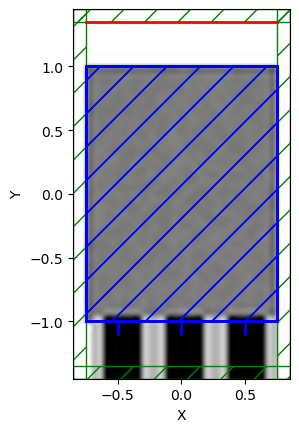

In [ ]:
import meep as mp
import meep.adjoint as mpa
import numpy as np
from autograd import numpy as npa
from autograd import tensor_jacobian_product as vjp
import nlopt
import matplotlib.pyplot as plt

mp.verbosity(0)

SiO2 = mp.Medium(epsilon=2.1)
Si3N4 = mp.Medium(epsilon=4.0)
PD = mp.Medium(epsilon=5.0)

design_w = 1.5
design_h = 2.0
pd_w = 0.3
pd_h = 0.5
dti_w = 0.2

cell_size = mp.Vector3(design_w + 0.2, design_h + pd_h + 0.4, 0)
pml_layers = [mp.PML(0.1)]
resolution = 100


# design region
Dx = 1.5
Dy = 2
design_region_resolution = int(resolution)
Nx = int(design_region_resolution * Dx) + 1
Ny = int(design_region_resolution * Dy) + 1

design_variables = mp.MaterialGrid(mp.Vector3(Nx,Ny,0),
                                   SiO2,
                                   Si3N4,
                                   grid_type="U_MEAN")
design_region = mpa.DesignRegion(design_variables,
                                 volume=mp.Volume(center=mp.Vector3(), size=mp.Vector3(Dx,Dy,0)))                             

geometry = []


# source
r_R = 0.65 # 650 nm
r_G = 0.55 # 550 nm
r_B = 0.45 # 450 nm
f_R = 1 / r_R
f_G = 1 / r_G
f_B = 1 / r_B

f_min = f_R
f_max = f_B
fcen = (f_min + f_max) / 2
df = (f_max - f_min) + 0.5

source_pos = 1.35
src = mp.GaussianSource(frequency=fcen, fwidth=df)

source = [
    mp.GaussianBeamSource(
        src,
        center=mp.Vector3(0, source_pos, 0),
        size=mp.Vector3(design_w, 0, 0),
        beam_w0=0.75,
        component=mp.Ez
    )
]


# geometry
geometry = [
    mp.Block(center=design_region.center,
             size=design_region.size,
             material=design_variables),
    
    # Red
    mp.Block(center=mp.Vector3(-0.5, -1.25, 0), 
             size=mp.Vector3(pd_w, pd_h, 0), 
             material=PD),
    # Green
    mp.Block(center=mp.Vector3(0, -1.25, 0), 
             size=mp.Vector3(pd_w, pd_h, 0), 
             material=PD),
    # Blue     
    mp.Block(center=mp.Vector3(0.5, -1.25, 0), 
             size=mp.Vector3(pd_w, pd_h, 0), 
             material=PD),

    mp.Block(center=mp.Vector3(-0.25, -1.25, 0), 
             size=mp.Vector3(dti_w, pd_h, 0),
               material=SiO2),
    mp.Block(center=mp.Vector3(0.25, -1.25, 0), 
             size=mp.Vector3(dti_w, pd_h, 0),
               material=SiO2),
    mp.Block(center=mp.Vector3(-0.7, -1.25, 0), 
             size=mp.Vector3(0.1, pd_h, 0),
               material=SiO2),
    mp.Block(center=mp.Vector3(0.7, -1.25, 0), 
             size=mp.Vector3(0.1, pd_h, 0),
               material=SiO2)       
]


# simulation
sim =mp.Simulation(
    cell_size=cell_size,
    boundary_layers=pml_layers,
    geometry=geometry,
    sources=source,
    resolution=resolution,
)


# monitor
frequencies = [f_R, f_G, f_B]

mon_R = mpa.FourierFields(sim, 
                          mp.Volume(center=mp.Vector3(-0.5, -1.05, 0), size=mp.Vector3(0,0.1,0)), 
                          mp.Ez, 
                          yee_grid=True)
mon_G = mpa.FourierFields(sim, 
                          mp.Volume(center=mp.Vector3(0, -1.05, 0), size=mp.Vector3(0,0.1,0)), 
                          mp.Ez, 
                          yee_grid=True)
mon_B = mpa.FourierFields(sim, 
                          mp.Volume(center=mp.Vector3(0.5, -1.05, 0), size=mp.Vector3(0,0.1,0)), 
                          mp.Ez, 
                          yee_grid=True)


# objective function
ob_list = [mon_R, mon_G, mon_B]

def J(R_fields, G_fields, B_fields):
    power_R = npa.abs(R_fields[0, 0]) ** 2
    power_G = npa.abs(G_fields[1, 0]) ** 2
    power_B = npa.abs(B_fields[2, 0]) ** 2

    alpha, beta, gamma = 1.0, 1.0, 1.0
    
    return alpha * power_R + beta * power_G + gamma * power_B

opt = mpa.OptimizationProblem(
    simulation=sim,
    objective_functions=J,
    objective_arguments=ob_list,
    design_regions=[design_region],
    frequencies=frequencies,
    decay_by=1e-3,
)


# filter
filter_radius = 0.08
eta = (0.5)

def mapping(x, beta):
    x_reshaped = npa.reshape(x,(Nx, Ny))

    # cone-shaped filter
    x_filtered = mpa.conic_filter(
        x_reshaped,
        filter_radius,
        design_region.size.x,
        design_region.size.y,
        design_region_resolution
    )

    # projection
    x_proj = mpa.tanh_projection(x_filtered, beta, eta)

    return x_proj.flatten()

np.random.seed(42)

x0 = 0.45 + 0.1 * np.random.rand(Nx * Ny)

opt.update_design([x0])

opt.plot2D(True)
plt.show()


In [6]:
evaluation_history = []
sensitivity = [0]
cur_iter = [0]

def f(x, gradient,beta):
    print("Current iteration: {}".format(cur_iter[0] + 1))

    f0, dJ_du = opt([mapping(x, beta)])
    
    if gradient.size > 0:
        g = np.array(dJ_du[0])
        g = np.real(np.ravel(g))

        gradient[:] = vjp(mapping, 0)(x, beta, g)
    
    evaluation_history.append(np.real(f0[0]))
    sensitivity[0] = dJ_du[0]
    cur_iter[0] += 1

    return np.real(f0[0])


algorithm = nlopt.LD_MMA
n = Nx * Ny

beta = 1   # 시작 β
beta_scale = 2        # β를 2배씩 키움
num_betas = 1     # β 단계 수 (총 6번)
update_factor = 10    # 각 β 단계에서 NLopt 반복 횟수(= maxeval)
for iters in range(num_betas):
    solver = nlopt.opt(algorithm, n)   # 매 β 단계마다 solver 새로 생성
    solver.set_lower_bounds(0)
    solver.set_upper_bounds(1)

    solver.set_max_objective(lambda a, g: f(a, g, beta))
    solver.set_maxeval(update_factor)

    x0[:] = solver.optimize(x0)
    beta = beta * beta_scale


opt.update_design([mapping(x0, beta)])
plt.figure(figsize=(8, 10))
opt.plot2D(True)
plt.show()

Current iteration: 1
Starting forward run...


KeyboardInterrupt: 